# **RQ3: How Does Dimensionality Affect RFM Behaviour Across Curvatures?**

Investigates how **intrinsic dimensionality** interacts with **curvature** to shape RFM behaviour.

In [1]:
from visualize_run import get_metrics
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats


Paths of different data outputs

In [2]:
mog_paths = [
    '../outputs/runs/mog/euclidean/general/*',
    '../outputs/runs/mog/sphere/general/*',
    '../outputs/runs/mog/poincare/general/*',
]

gtg_paths = [
    '../outputs/runs/gtg/euclidean/general/*',
    '../outputs/runs/gtg/sphere/general/*',
    '../outputs/runs/gtg/poincare/general/*',
]

gaussian_ring_paths = [
    '../outputs/runs/general_fm/fm/2026.05.21/*'
]

checkerboard_paths = [
    '../outputs/runs/checkerboard/euclidean/general/*',
    '../outputs/runs/checkerboard/sphere/general/*',
    '../outputs/runs/checkerboard/poincare/general/*',
]

gtg_norm_paths = [
    '../outputs/runs/gtg/euclidean/norm/*',
    '../outputs/runs/gtg/sphere/norm/*',
    '../outputs/runs/gtg/poincare/norm/*',
]

In [3]:
# Load fresh and save:
# metrics_gtg = get_metrics([], gtg_paths, visualize=False, save=True, out_dir='runs/gtg')

metrics_gtg_norm = get_metrics([], gtg_paths, visualize=False, save=True, out_dir='runs/gtg_norm')
# metrics_mog = get_metrics([], mog_paths, visualize=False, save=True, out_dir='runs/mog')
#metrics_gaussian_ring = get_metrics([], gaussian_ring_paths, visualize=False, save=True, out_dir='runs/gaussian_ring')
# metrics_checkerboard = get_metrics([], checkerboard_paths, visualize=False, save=True, out_dir='runs/checkerboard')

# Load from cache:
metrics_gtg = pd.read_csv('runs/gtg/metrics.csv')
metrics_gtg_norm = pd.read_csv('runs/gtg_norm/metrics.csv')
metrics_mog = pd.read_csv('runs/mog/metrics.csv')
metrics_gaussian_ring = pd.read_csv('runs/gaussian_ring/metrics.csv')
metrics_checkerboard = pd.read_csv('runs/checkerboard/metrics.csv')

SKIP (missing files):
  - missing artifacts file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/gtg/sphere/general/sph_d5_c10_s50/artifacts/final_fixed_eval_outputs.pt
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/gtg/sphere/general/sph_d5_c10_s50/metrics.json
SKIP (missing files):
  - missing artifacts file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/gtg/poincare/general/poi_d8_c1_s42/artifacts/final_fixed_eval_outputs.pt
  - missing metrics file: /gpfs/home6/scur0108/DL2_project/Spherical-Flow-Matching/riemannian-fm/outputs/runs/gtg/poincare/general/poi_d8_c1_s42/metrics.json


In [4]:

PERF_COL     = "test_sample/sinkhorn_knopp"
VGG_COL      = "test_sample/volume_scaling_gap_target_minus_pred"
DIM_COL      = "dim"
MANIFOLD_COL = "manifold"
CURV_COL     = "curvature"

EUCLIDEAN_NAME = "euclidean"
POINCARE_NAME  = "poincare"
SPHERE_NAME    = "sphere"

# S^n stored as dim=n+1 (ambient). True -> subtract 1 for intrinsic dim.
SPHERE_DIM_MINUS_ONE = True

# Error bars: "sem" or "std"
ERROR_BAR = "sem"

# Curvatures shown in the main-text line plot (None = show all)
SELECTED_CURVATURES = [1, 3, 10]

# Curvature ordering: "abs" = by magnitude, "numeric" = signed
CURVATURE_ORDER = "abs"



def signed_log1p(x):
    return np.sign(x) * np.log10(1 + np.abs(x))

def safe_log10(x):
    x = pd.to_numeric(x, errors="coerce")
    return np.log10(x.where(x > 0))

def error_value(x, kind="sem"):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) <= 1: return 0.0
    if kind == "std": return x.std(ddof=1)
    return x.std(ddof=1) / np.sqrt(len(x))

def mean_sem(x):
    x = pd.Series(x).replace([np.inf, -np.inf], np.nan).dropna()
    if len(x) == 0: return np.nan, np.nan, 0
    mean = x.mean()
    if len(x) == 1: return mean, 0.0, 1
    return mean, x.std(ddof=1) / np.sqrt(len(x)), len(x)

def nice_dim_label(x):
    if pd.isna(x): return ""
    return str(int(x)) if float(x).is_integer() else f"{x:g}"

def nice_curv_label(x):
    if pd.isna(x): return "NA"
    try: return f"{float(x):g}"
    except Exception: return str(x)

def display_manifold_name(m):
    return {POINCARE_NAME: "Hyperbolic", SPHERE_NAME: "Spherical",
            EUCLIDEAN_NAME: "Euclidean"}.get(m, str(m))

def ordered_curvatures(values, order="abs"):
    values = pd.Series(values).dropna().unique()
    def key(x):
        try:
            xf = float(x)
            return (abs(xf), xf) if order == "abs" else (xf,)
        except Exception: return (str(x),)
    return sorted(values, key=key)

def ordered_manifolds(values):
    preferred = [POINCARE_NAME, SPHERE_NAME, EUCLIDEAN_NAME]
    values = list(pd.Series(values).dropna().unique())
    return [m for m in preferred if m in values] + [m for m in values if m not in preferred]

def ordered_values_numeric(values, use_abs=False):
    values = pd.Series(values).dropna().unique()
    def key(x):
        try:
            xf = float(x)
            return (abs(xf), xf) if use_abs else (xf,)
        except Exception: return (str(x),)
    return sorted(values, key=key)



def add_relative_to_euclidean(df_prepared, metric_col, out_col):
    df = df_prepared.copy()
    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_metric=(metric_col, "mean"))
    )
    df = df.merge(euc, on="compare_dim", how="left")
    df[out_col] = df[metric_col] / df["euc_metric"]
    return df

def prepare_rq3_dataframe(df):
    """
    Adds: compare_dim, euc_perf/euc_vgg baselines,
    rel_perf, log_rel_perf, vgg_gap_vs_euc, signed_log_vgg_gap.
    """
    df = df.copy()
    df[PERF_COL] = pd.to_numeric(df[PERF_COL], errors="coerce")
    df[VGG_COL]  = pd.to_numeric(df[VGG_COL],  errors="coerce")
    df[DIM_COL]  = pd.to_numeric(df[DIM_COL],  errors="coerce")

    df["compare_dim"] = df[DIM_COL]
    if SPHERE_DIM_MINUS_ONE:
        mask = df[MANIFOLD_COL].eq(SPHERE_NAME)
        df.loc[mask, "compare_dim"] = df.loc[mask, DIM_COL] - 1

    euc = (
        df[df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)]
        .groupby("compare_dim", as_index=False)
        .agg(euc_perf=(PERF_COL, "mean"), euc_vgg=(VGG_COL, "mean"))
    )
    euc["euc_vgg"] = euc["euc_vgg"].fillna(0.0)
    df = df.merge(euc, on="compare_dim", how="left")

    df["rel_perf"]        = df[PERF_COL] / df["euc_perf"]
    df["log_rel_perf"]    = np.log10(df["rel_perf"])
    df["vgg_gap_vs_euc"]  = df[VGG_COL] - df["euc_vgg"]
    df["signed_log_vgg_gap"] = signed_log1p(df["vgg_gap_vs_euc"])
    return df


rq3_prepared = prepare_rq3_dataframe(metrics_gtg)
rq3_prepared_norm = prepare_rq3_dataframe(metrics_gtg_norm)
rq3_prepared_mog = prepare_rq3_dataframe(metrics_mog)
rq3_prepared_gaussian_ring = prepare_rq3_dataframe(metrics_gaussian_ring)
rq3_prepared_checkerboard = prepare_rq3_dataframe(metrics_checkerboard)
print(f"Loaded {len(rq3_prepared)} rows.")
print(f"Manifolds:  {sorted(rq3_prepared[MANIFOLD_COL].dropna().unique())}")
print(f"Curvatures: {sorted(rq3_prepared[CURV_COL].dropna().unique())}")
print(f"Dimensions: {sorted(rq3_prepared['compare_dim'].dropna().unique())}")


Loaded 243 rows.
Manifolds:  ['euclidean', 'poincare', 'sphere']
Curvatures: [0.0, 1.0, 2.0, 3.0, 5.0, 10.0]
Dimensions: [2, 3, 4, 8, 16, 64, 256, 512]


In [5]:
def make_curvature_dimension_surface(
    df_prepared, metric_col, value_col_name="value",
    relative_to_euclidean=False, log10_value=False,
    signed_log_value=False, exclude_euclidean=True,
):
    df = df_prepared.copy()
    df[metric_col] = pd.to_numeric(df[metric_col], errors="coerce")
    if relative_to_euclidean:
        rel_col = f"{metric_col}_rel_euc"
        df = add_relative_to_euclidean(df, metric_col, rel_col)
        base_col = rel_col
    else:
        base_col = metric_col
    if log10_value:
        df[value_col_name] = safe_log10(df[base_col])
    elif signed_log_value:
        df[value_col_name] = signed_log1p(df[base_col])
    else:
        df[value_col_name] = df[base_col]
    if exclude_euclidean:
        df = df[~df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    rows = []
    for keys, sub in df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], dropna=False):
        manifold, curvature, dim = keys
        mean, sem, n = mean_sem(sub[value_col_name])
        rows.append({MANIFOLD_COL: manifold, CURV_COL: curvature,
                     "compare_dim": dim, "mean": mean, "sem": sem, "n": n})
    return pd.DataFrame(rows)


def plot_curvature_dimension_heatmaps(
    surface_df, title, cbar_label,
    manifolds=(POINCARE_NAME, SPHERE_NAME),
    annotate=True, cmap="RdBu_r", curvature_order_abs=True,
):
    manifolds = [m for m in manifolds if m in surface_df[MANIFOLD_COL].unique()]
    fig, axes = plt.subplots(1, len(manifolds),
                             figsize=(6.2 * len(manifolds), 4.2), squeeze=False)
    axes = axes[0]
    vals = surface_df["mean"].replace([np.inf, -np.inf], np.nan)
    abs_max = max(abs(np.nanmin(vals)), abs(np.nanmax(vals)))
    vmin, vmax = -abs_max, abs_max

    for ax, manifold in zip(axes, manifolds):
        sub = surface_df[surface_df[MANIFOLD_COL].eq(manifold)].copy()
        dims       = ordered_values_numeric(sub["compare_dim"])
        curvatures = ordered_values_numeric(sub[CURV_COL], use_abs=curvature_order_abs)
        pivot = (
            sub.pivot_table(index=CURV_COL, columns="compare_dim",
                            values="mean", aggfunc="mean")
            .reindex(index=curvatures, columns=dims)
        )
        im = ax.imshow(pivot.values, aspect="auto", cmap=cmap,
                       vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_xticks(range(len(dims)))
        ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45, ha="right")
        ax.set_yticks(range(len(curvatures)))
        ax.set_yticklabels([nice_curv_label(c) for c in curvatures])
        ax.set_xlabel("Dimension")
        ax.set_ylabel("Curvature |k|")
        ax.set_title(display_manifold_name(manifold))
        if annotate:
            for ri in range(pivot.shape[0]):
                for ci in range(pivot.shape[1]):
                    val = pivot.iloc[ri, ci]
                    if not np.isnan(val):
                        tc = "white" if abs(val) > 0.45 * abs_max else "black"
                        ax.text(ci, ri, f"{val:.2f}",
                                ha="center", va="center", fontsize=7.5, color=tc)
        plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)
    fig.suptitle(title, fontsize=13, y=1.02)
    fig.tight_layout()
    return fig, axes


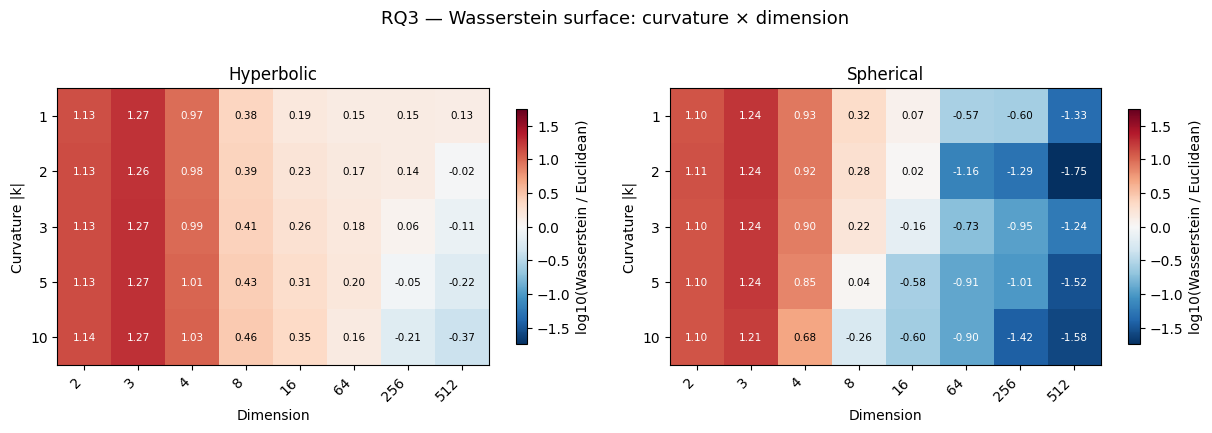

In [6]:
wasserstein_surface = make_curvature_dimension_surface(
    rq3_prepared, metric_col=PERF_COL,
    value_col_name="log_rel_wasserstein",
    relative_to_euclidean=True, log10_value=True,
)
fig_wh, _ = plot_curvature_dimension_heatmaps(
    wasserstein_surface,
    title="RQ3 — Wasserstein surface: curvature × dimension",
    cbar_label="log10(Wasserstein / Euclidean)",
)
plt.show()
# fig_wh.savefig("rq3_heatmap_wasserstein.png", dpi=300, bbox_inches="tight")


Observations

The hyperbolic model perform exceptionally well for the higher dimensions, evenmore so for the Sphere.

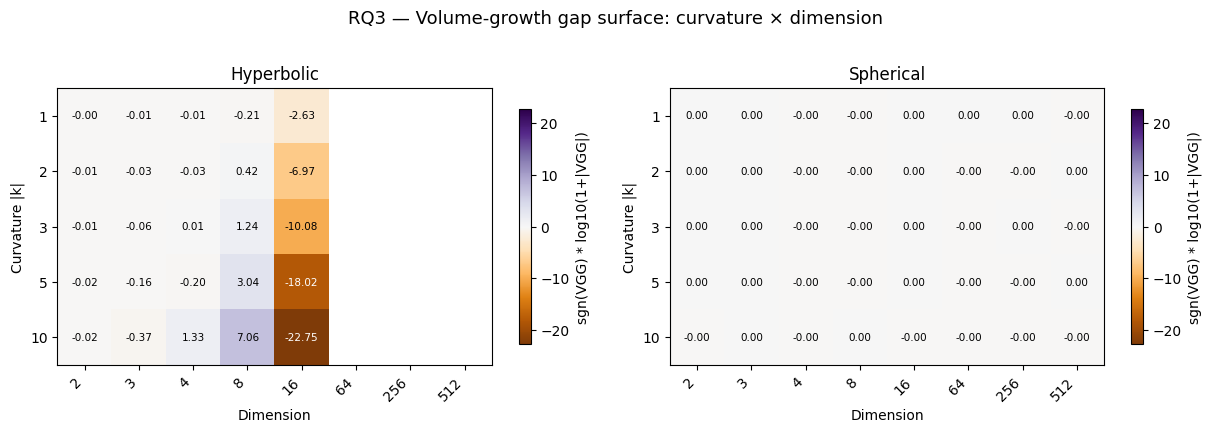

In [7]:
vgg_surface = make_curvature_dimension_surface(
    rq3_prepared, metric_col=VGG_COL,
    value_col_name="signed_log_vgg",
    signed_log_value=True,
)
fig_vh, _ = plot_curvature_dimension_heatmaps(
    vgg_surface,
    title="RQ3 — Volume-growth gap surface: curvature × dimension",
    cbar_label="sgn(VGG) * log10(1+|VGG|)",
    cmap="PuOr",
)
plt.show()


In [8]:
def plot_wasserstein_vs_dim(df_prepared, selected_curvatures=None, title_suffix=""):
    """
    One subplot per manifold (Hyperbolic, Spherical).
    x: compare_dim (log2)  y: log_rel_perf  lines: one per curvature
    """
    df = df_prepared[~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    if selected_curvatures is not None:
        df = df[df[CURV_COL].isin(selected_curvatures)]

    manifolds = [m for m in ordered_manifolds(df[MANIFOLD_COL]) if m != EUCLIDEAN_NAME]
    grouped = (
        df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], as_index=False)
        .agg(
            y_mean=("log_rel_perf", "mean"),
            y_sem=("log_rel_perf",  lambda x: error_value(x, ERROR_BAR)),
            n=("log_rel_perf", "count"),
        )
    )

    all_curvs = ordered_curvatures(grouped[CURV_COL], order=CURVATURE_ORDER)
    cmap = plt.cm.viridis
    color_map = {c: cmap(v) for c, v in
                 zip(all_curvs, np.linspace(0.1, 0.9, len(all_curvs)))}

    fig, axes = plt.subplots(1, len(manifolds),
                             figsize=(6.5 * len(manifolds), 4.8), sharey=True)
    if len(manifolds) == 1: axes = [axes]

    for ax, manifold in zip(axes, manifolds):
        sub_m = grouped[grouped[MANIFOLD_COL].eq(manifold)]
        for curvature in ordered_curvatures(sub_m[CURV_COL], order=CURVATURE_ORDER):
            sub = sub_m[sub_m[CURV_COL].eq(curvature)].sort_values("compare_dim")
            if sub.empty: continue
            color = color_map[curvature]
            d, ym, ys = sub["compare_dim"].values, sub["y_mean"].values, sub["y_sem"].values
            ax.fill_between(d, ym - ys, ym + ys, alpha=0.15, color=color)
            ax.errorbar(d, ym, yerr=ys, fmt="o-", color=color, markersize=6,
                        capsize=4, linewidth=2, label=f"k={nice_curv_label(curvature)}")

        ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.6)
        ax.set_xscale("log", base=2)
        dims_all = sorted(sub_m["compare_dim"].dropna().unique())
        ax.set_xticks(dims_all)
        ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
        ax.set_xlabel("Intrinsic dimension", fontsize=11)
        ax.set_title(display_manifold_name(manifold), fontsize=12)
        ax.legend(frameon=False, title="Curvature", fontsize=9)
        ax.grid(alpha=0.2)
        ax.text(0.02, 0.98, "Above 0: worse than Euclidean\nBelow 0: better than Euclidean",
                transform=ax.transAxes, fontsize=8, va="top", color="grey")

    axes[0].set_ylabel("log10(Wasserstein / Euclidean baseline)", fontsize=11)
    suffix = f" — {title_suffix}" if title_suffix else ""
    fig.suptitle(f"RQ3: Wasserstein vs. dimensionality{suffix}", fontsize=14)
    fig.tight_layout()
    return fig, axes


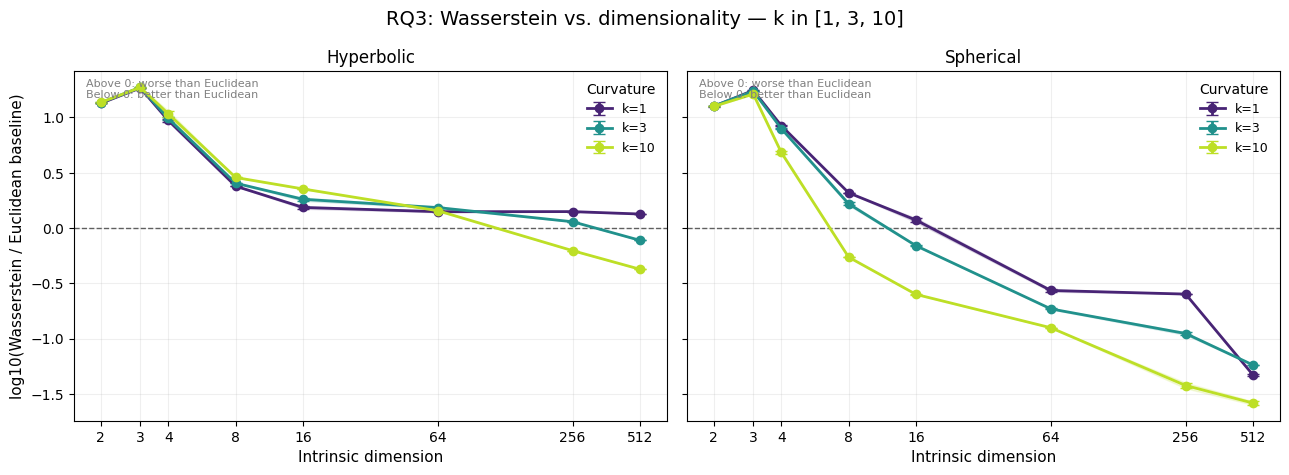

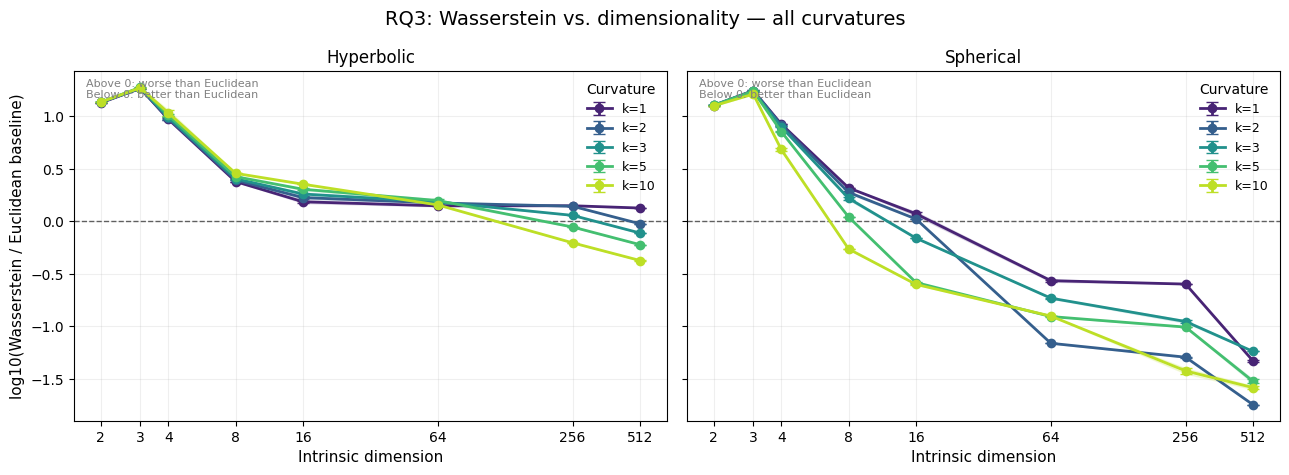

In [9]:
# Main text: selected curvatures
fig_main, _ = plot_wasserstein_vs_dim(
    rq3_prepared,
    selected_curvatures=SELECTED_CURVATURES,
    title_suffix=f"k in {SELECTED_CURVATURES}",
)
plt.show()
# fig_main.savefig("rq3_wasserstein_vs_dim_main.png", dpi=300, bbox_inches="tight")

# Appendix version: all curvatures
fig_all, _ = plot_wasserstein_vs_dim(rq3_prepared, title_suffix="all curvatures")
plt.show()


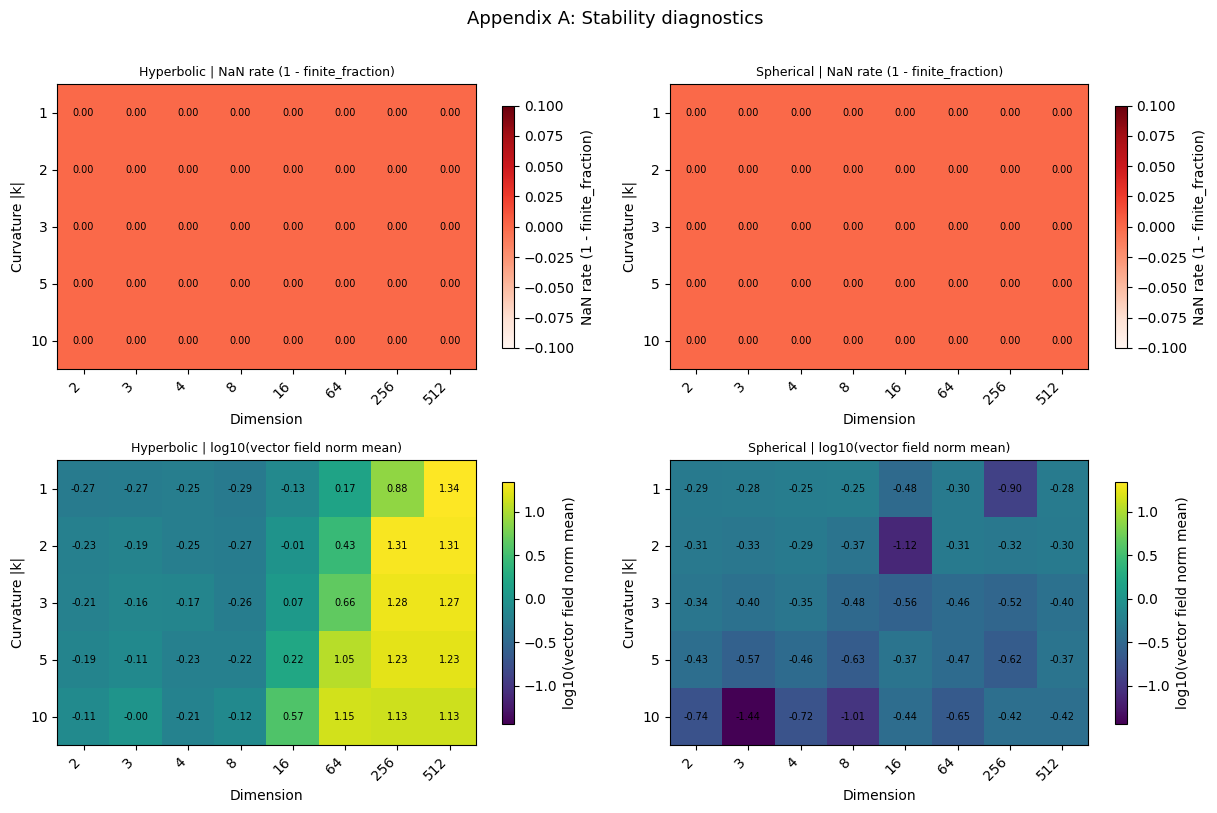

In [10]:
def plot_stability_heatmaps(df_prepared):
    """
    Row 1: NaN rate (Reds)         Row 2: log10(norm mean) (viridis)
    Columns: one per manifold
    """
    df = df_prepared.copy()
    df["nan_rate"] = 1.0 - pd.to_numeric(df.get("test_vec/finite_fraction"), errors="coerce")
    df["log_norm"] = safe_log10(pd.to_numeric(df.get("test_vec/norm_mean"), errors="coerce"))

    metric_specs = [
        ("nan_rate", "NaN rate (1 - finite_fraction)", "Reds"),
        ("log_norm", "log10(vector field norm mean)",  "viridis"),
    ]
    manifolds = [m for m in [POINCARE_NAME, SPHERE_NAME]
                 if m in df[MANIFOLD_COL].unique()]

    fig, axes = plt.subplots(len(metric_specs), len(manifolds),
                             figsize=(6.2 * len(manifolds), 4.0 * len(metric_specs)),
                             squeeze=False)

    for row_i, (metric_col, cbar_label, cmap_name) in enumerate(metric_specs):
        sub_df = df[~df[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
        rows = []
        for keys, sub in sub_df.groupby(
            [MANIFOLD_COL, CURV_COL, "compare_dim"], dropna=False
        ):
            m_name, curv, dim = keys
            mean, sem, n = mean_sem(sub[metric_col].replace([np.inf, -np.inf], np.nan))
            rows.append({MANIFOLD_COL: m_name, CURV_COL: curv,
                         "compare_dim": dim, "mean": mean})
        surface = pd.DataFrame(rows)
        vals = surface["mean"].replace([np.inf, -np.inf], np.nan)
        vmin, vmax = np.nanmin(vals), np.nanmax(vals)

        for col_i, manifold in enumerate(manifolds):
            ax = axes[row_i][col_i]
            sub_m = surface[surface[MANIFOLD_COL].eq(manifold)]
            dims       = ordered_values_numeric(sub_m["compare_dim"])
            curvatures = ordered_values_numeric(sub_m[CURV_COL], use_abs=True)
            pivot = (
                sub_m.pivot_table(index=CURV_COL, columns="compare_dim",
                                  values="mean", aggfunc="mean")
                .reindex(index=curvatures, columns=dims)
            )
            im = ax.imshow(pivot.values, aspect="auto", cmap=cmap_name,
                           vmin=vmin, vmax=vmax, interpolation="nearest")
            ax.set_xticks(range(len(dims)))
            ax.set_xticklabels([nice_dim_label(d) for d in dims], rotation=45, ha="right")
            ax.set_yticks(range(len(curvatures)))
            ax.set_yticklabels([nice_curv_label(c) for c in curvatures])
            ax.set_xlabel("Dimension")
            ax.set_ylabel("Curvature |k|")
            ax.set_title(f"{display_manifold_name(manifold)} | {cbar_label}", fontsize=9)
            for ri in range(pivot.shape[0]):
                for ci in range(pivot.shape[1]):
                    v = pivot.iloc[ri, ci]
                    if not np.isnan(v):
                        ax.text(ci, ri, f"{v:.2f}", ha="center", va="center", fontsize=7)
            plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.85)

    fig.suptitle("Appendix A: Stability diagnostics", fontsize=13, y=1.01)
    fig.tight_layout()
    return fig, axes


fig_stab, _ = plot_stability_heatmaps(rq3_prepared)
plt.show()


In [11]:
def make_training_time_table(df_raw, df_prepared):
    
    time_candidates = [c for c in df_raw.columns if "nfe" in c.lower()]
    
    if not time_candidates:
        print("No NFE or cost column found.")
        return None
        
    time_col = time_candidates[0]
    print(f"Using column: '{time_col}' as computational cost proxy")

    df = df_prepared.copy()
    df["_time"] = pd.to_numeric(df_raw[time_col], errors="coerce")
    rows = []
    for (manifold, dim), sub in df.groupby([MANIFOLD_COL, "compare_dim"]):
        t = sub["_time"].replace([np.inf, -np.inf], np.nan).dropna()
        mean, sem, n = mean_sem(t)
        rows.append({
            "Manifold":  display_manifold_name(manifold),
            "Dimension": int(dim) if float(dim).is_integer() else dim,
            "Mean NFE":  f"{mean:.1f}" if not np.isnan(mean) else "---",  
            "SEM":       f"{sem:.1f}"  if not np.isnan(sem)  else "---",
            "n runs":    n,
        })
    return pd.DataFrame(rows).sort_values(["Manifold", "Dimension"]).reset_index(drop=True)


tt_table = make_training_time_table(metrics_gtg, rq3_prepared)
if tt_table is not None:
    display(tt_table)
    # tt_table.to_csv("rq3_training_time.csv", index=False)


Using column: 'nfe' as computational cost proxy


,Manifold,Dimension,Mean NFE,SEM,n runs
0,Euclidean,2,43.3,5.1,3
1,Euclidean,3,39.8,2.1,3
2,Euclidean,4,36.0,2.0,3
3,Euclidean,8,36.0,2.0,3
4,Euclidean,16,31.0,5.5,3
5,Euclidean,64,20.0,0.0,3
6,Euclidean,256,20.0,0.0,3
7,Euclidean,512,20.0,0.0,3
8,Hyperbolic,2,45.1,1.7,15
9,Hyperbolic,3,54.7,4.2,15


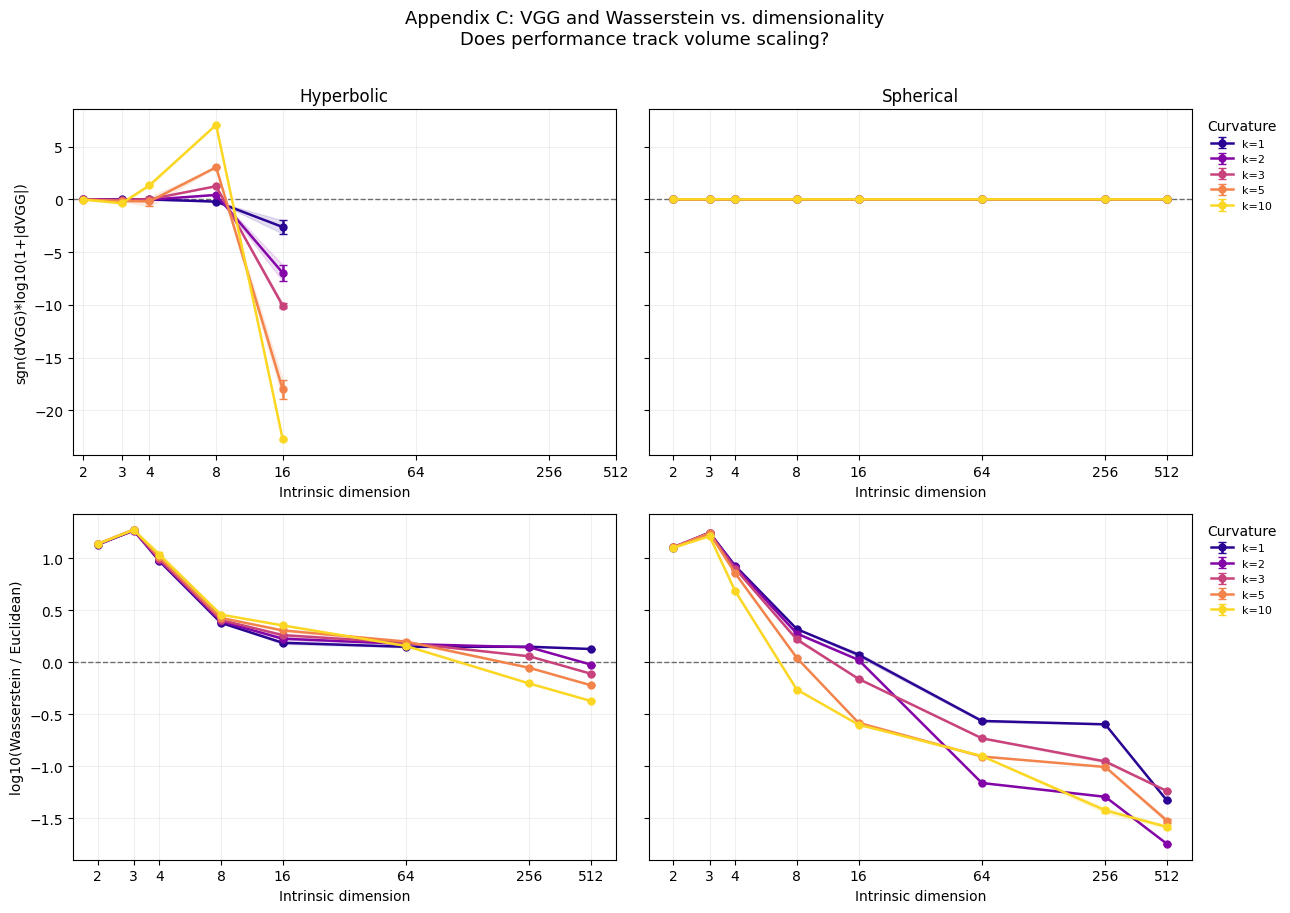

In [12]:
def plot_vgg_and_wasserstein_vs_dim(df_prepared, selected_curvatures=None):
    """
    2-row x n_manifold-column figure.
    Row 1: VGG gap vs dimension   Row 2: Wasserstein vs dimension
    Same colour map across rows so the two are visually linked.
    """
    df = df_prepared[~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)].copy()
    df = df.replace([np.inf, -np.inf], np.nan)
    if selected_curvatures is not None:
        df = df[df[CURV_COL].isin(selected_curvatures)]

    manifolds = [m for m in ordered_manifolds(df[MANIFOLD_COL]) if m != EUCLIDEAN_NAME]
    all_curvs = ordered_curvatures(df[CURV_COL], order=CURVATURE_ORDER)
    cmap = plt.cm.plasma
    color_map = {c: cmap(v) for c, v in
                 zip(all_curvs, np.linspace(0.05, 0.92, len(all_curvs)))}

    grouped = (
        df.groupby([MANIFOLD_COL, CURV_COL, "compare_dim"], as_index=False)
        .agg(
            vgg_mean=("signed_log_vgg_gap", "mean"),
            vgg_sem=("signed_log_vgg_gap",  lambda x: error_value(x, ERROR_BAR)),
            wass_mean=("log_rel_perf", "mean"),
            wass_sem=("log_rel_perf",  lambda x: error_value(x, ERROR_BAR)),
            n=(PERF_COL, "count"),
        )
    )

    row_specs = [
        ("vgg_mean",  "vgg_sem",  "sgn(dVGG)*log10(1+|dVGG|)"),
        ("wass_mean", "wass_sem", "log10(Wasserstein / Euclidean)"),
    ]
    row_titles = ["Row 1: Volume-growth gap", "Row 2: RFM performance"]

    fig, axes = plt.subplots(
        2, len(manifolds),
        figsize=(6.5 * len(manifolds), 4.5 * 2),
        sharey="row", squeeze=False,
    )

    for col_i, manifold in enumerate(manifolds):
        sub_m = grouped[grouped[MANIFOLD_COL].eq(manifold)]
        curvatures = ordered_curvatures(sub_m[CURV_COL], order=CURVATURE_ORDER)
        dims_all = sorted(sub_m["compare_dim"].dropna().unique())

        for row_i, (y_col, e_col, ylabel) in enumerate(row_specs):
            ax = axes[row_i][col_i]
            for curvature in curvatures:
                sub = sub_m[sub_m[CURV_COL].eq(curvature)].sort_values("compare_dim")
                if sub.empty: continue
                color = color_map[curvature]
                d, ym, ys = sub["compare_dim"].values, sub[y_col].values, sub[e_col].values
                ax.fill_between(d, ym - ys, ym + ys, alpha=0.12, color=color)
                ax.errorbar(d, ym, yerr=ys, fmt="o-", color=color, markersize=5,
                            capsize=3, linewidth=1.8,
                            label=f"k={nice_curv_label(curvature)}")
            ax.axhline(0, color="black", linestyle="--", linewidth=1, alpha=0.55)
            ax.set_xscale("log", base=2)
            ax.set_xticks(dims_all)
            ax.xaxis.set_major_formatter(mticker.ScalarFormatter())
            ax.set_xlabel("Intrinsic dimension")
            ax.grid(alpha=0.2)
            if col_i == 0:
                ax.set_ylabel(ylabel, fontsize=10)
            if row_i == 0:
                ax.set_title(display_manifold_name(manifold), fontsize=12)
            if col_i == len(manifolds) - 1:
                ax.legend(frameon=False, title="Curvature", fontsize=8,
                          loc="upper left", bbox_to_anchor=(1.01, 1))

    fig.suptitle(
        "Appendix C: VGG and Wasserstein vs. dimensionality\n"
        "Does performance track volume scaling?",
        fontsize=13, y=1.01,
    )
    fig.tight_layout()
    return fig, axes


fig_dual, _ = plot_vgg_and_wasserstein_vs_dim(rq3_prepared)
plt.show()
# fig_dual.savefig("rq3_appendix_c_vgg_wasserstein.png", dpi=300, bbox_inches="tight")


In [13]:
def make_spearman_by_dim_table(df_prepared):
    df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy().replace([np.inf, -np.inf], np.nan)

    grouped = (
        df.groupby(["compare_dim", MANIFOLD_COL, CURV_COL], as_index=False)
        .agg(wass=("log_rel_perf", "mean"), vgg=("signed_log_vgg_gap", "mean"))
    )

    dims = sorted(grouped["compare_dim"].dropna().unique())
    rows = []
    for dim in dims:
        sub = grouped[grouped["compare_dim"].eq(dim)].dropna(subset=["wass", "vgg"])
        n = len(sub)
        if n >= 3:
            rho, pval = stats.spearmanr(sub["vgg"], sub["wass"])
        else:
            rho, pval = np.nan, np.nan
        rows.append({
            "Dimension":      int(dim) if float(dim).is_integer() else dim,
            "n experiments":  n,
            "Spearman rho":   round(rho, 3) if not np.isnan(rho) else "---",
            "p-value":        f"{pval:.3f}" if not np.isnan(pval) else "---",
        })

    pooled = grouped.dropna(subset=["wass", "vgg"])
    rho_all, pval_all = (stats.spearmanr(pooled["vgg"], pooled["wass"])
                         if len(pooled) >= 3 else (np.nan, np.nan))
    rows.append({
        "Dimension":     "All (pooled)",
        "n experiments": len(pooled),
        "Spearman rho":  round(rho_all, 3) if not np.isnan(rho_all) else "---",
        "p-value":       f"{pval_all:.3f}" if not np.isnan(pval_all) else "---",
    })

    return pd.DataFrame(rows)


spearman_dim_table = make_spearman_by_dim_table(rq3_prepared)
display(spearman_dim_table)
# spearman_dim_table.to_csv("rq3_spearman_by_dim.csv", index=False)


,Dimension,n experiments,Spearman rho,p-value
0,2,10,-0.782,0.008
1,3,10,-0.915,0.000
2,4,10,0.103,0.777
3,8,10,0.685,0.029
4,16,10,-0.758,0.011
5,64,5,0.300,0.624
6,256,5,1.000,0.000
7,512,5,-0.821,0.089
8,All (pooled),65,-0.113,0.372


In [14]:
def plot_rq3_dimension_vs_performance(
    summary,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    specs = get_rq3_style_specs(summary)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs["group_specs"]:
        sub = spec["sub"].dropna(
            subset=["compare_dim", "log_rel_perf_mean"]
        ).sort_values("compare_dim")

        if sub.empty:
            continue

        ax.errorbar(
            sub["compare_dim"],
            sub["log_rel_perf_mean"],
            yerr=sub["log_rel_perf_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_dimension_axis(ax, summary)

    # ax.set_title(r"Relative performance across dimension")
    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(
        r"$\log_{10}\!\left(\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}\right)$"
    )

    # ax.text(
    #     0.02,
    #     0.02,
    #     r"$>0$: worse than Euclidean" "\n" r"$<0$: better than Euclidean",
    #     transform=ax.transAxes,
    #     fontsize=14,
    #     va="top",
    #     ha="center",
    # )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, ax

In [25]:
def plot_rq3_performance(
    summary1,
    summary2,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    specs = get_rq3_style_specs(summary1)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs["group_specs"]:
        manifold = spec["manifold"]
        curvature = spec["curvature"]

        sub1 = (
            summary1[
                summary1[MANIFOLD_COL].eq(manifold)
                & summary1[CURV_COL].eq(curvature)
            ]
            .dropna(subset=["compare_dim", "log_rel_perf_mean"])
            .sort_values("compare_dim")
        )

        sub2 = (
            summary2[
                summary2[MANIFOLD_COL].eq(manifold)
                & summary2[CURV_COL].eq(curvature)
            ]
            .dropna(subset=["compare_dim", "log_rel_perf_mean"])
            .sort_values("compare_dim")
        )

        if sub1.empty or sub2.empty:
            continue

        merged = pd.merge(
            sub1,
            sub2,
            on=["compare_dim", MANIFOLD_COL, CURV_COL],
            suffixes=("_1", "_2"),
        )

        if merged.empty:
            continue

        merged["diff_mean"] = (
            merged["log_rel_perf_mean_1"]
            - merged["log_rel_perf_mean_2"]
        )

        merged["diff_err"] = np.sqrt(
            merged["log_rel_perf_err_1"] ** 2
            + merged["log_rel_perf_err_2"] ** 2
        )

        ax.errorbar(
            merged["compare_dim"],
            merged["diff_mean"],
            yerr=merged["diff_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_dimension_axis(ax, summary1)

    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(
        r"$\Delta \log_{10}\!\left("
        r"\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}"
        r"\right)$"
    )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, ax

In [16]:
def plot_rq3_2plots(
    summary1,
    summary2,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="center right",
):
    specs = get_rq3_style_specs(summary1)

    fig, ax = plt.subplots(figsize=figsize)

    for spec in specs["group_specs"]:
        manifold = spec["manifold"]
        curvature = spec["curvature"]

        sub1 = (
            summary1[
                summary1[MANIFOLD_COL].eq(manifold)
                & summary1[CURV_COL].eq(curvature)
            ]
            .dropna(subset=["compare_dim", "log_rel_perf_mean"])
            .sort_values("compare_dim")
        )

        sub2 = (
            summary2[
                summary2[MANIFOLD_COL].eq(manifold)
                & summary2[CURV_COL].eq(curvature)
            ]
            .dropna(subset=["compare_dim", "log_rel_perf_mean"])
            .sort_values("compare_dim")
        )

        if sub1.empty or sub2.empty:
            continue

        merged = pd.merge(
            sub1,
            sub2,
            on=["compare_dim", MANIFOLD_COL, CURV_COL],
            suffixes=("_1", "_2"),
        )

        if merged.empty:
            continue

        merged["diff_mean"] = (
            merged["log_rel_perf_mean_1"]
            - merged["log_rel_perf_mean_2"]
        )

        merged["diff_err"] = np.sqrt(
            merged["log_rel_perf_err_1"] ** 2
            + merged["log_rel_perf_err_2"] ** 2
        )

        ax.errorbar(
            merged["compare_dim"],
            merged["diff_mean"],
            yerr=merged["diff_err"],
            fmt=spec["marker"],
            color=spec["color"],
            markersize=7,
            capsize=3,
            linewidth=1.5,
            alpha=0.85,
            linestyle=spec["linestyle"],
        )

    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.6)

    format_dimension_axis(ax, summary1)

    ax.set_xlabel(r"Dimension $d$")
    ax.set_ylabel(
        r"$\Delta \log_{10}\!\left("
        r"\mathcal{W}_{\mathcal{M}}"
        r"/\mathcal{W}_{\mathrm{Euc}}"
        r"\right)$"
    )

    ax.grid(alpha=0.2)

    add_grouped_curvature_legends(
        ax,
        specs,
        hyp_loc=hyp_legend_loc,
        sph_loc=sph_legend_loc,
        fontsize=14,
    )

    fig.tight_layout()

    return fig, ax

In [17]:
def summarize_for_curvature_plot(df_prepared):
    """
    Averages over seeds for each:
        dimension × manifold × curvature
    """

    plot_df = df_prepared[
        ~df_prepared[MANIFOLD_COL].eq(EUCLIDEAN_NAME)
    ].copy()

    group_cols = ["compare_dim", MANIFOLD_COL, CURV_COL]

    rows = []

    for keys, sub in plot_df.groupby(group_cols, dropna=False):
        compare_dim, manifold, curvature = keys

        row = {
            "compare_dim": compare_dim,
            MANIFOLD_COL: manifold,
            CURV_COL: curvature,
        }

        y = sub["log_rel_perf"].replace([np.inf, -np.inf], np.nan).dropna()
        row["log_rel_perf_mean"] = y.mean()
        row["log_rel_perf_err"] = error_value(y, ERROR_BAR)
        row["log_rel_perf_n"] = len(y)
        row["perf_mean"] = sub[PERF_COL].mean()
        row["perf"] = sub[PERF_COL]
        row["perf_err"] = error_value(sub[PERF_COL], ERROR_BAR)

        x = sub["signed_log_vgg_gap"].replace([np.inf, -np.inf], np.nan).dropna()
        row["signed_log_vgg_gap_mean"] = x.mean()
        row["signed_log_vgg_gap_err"] = error_value(x, ERROR_BAR)
        row["signed_log_vgg_gap_n"] = len(x)

        rows.append(row)

    return pd.DataFrame(rows)

In [18]:
def get_rq3_style_specs(summary):
    marker_map = {
        POINCARE_NAME: "X",
        SPHERE_NAME: "1",
    }

    line_map = {
        POINCARE_NAME: "solid",
        SPHERE_NAME: "dashed",
    }

    manifold_cmap_map = {
        POINCARE_NAME: plt.cm.YlOrBr,
        SPHERE_NAME: plt.cm.BuGn,
    }

    pooled_color_map = {
        POINCARE_NAME: plt.cm.YlOrBr(0.75),
        SPHERE_NAME: plt.cm.BuGn(0.75),
    }

    manifolds = ordered_manifolds(summary[MANIFOLD_COL])
    curvatures = ordered_curvatures(summary[CURV_COL], order=CURVATURE_ORDER)

    curvature_color_map = {}

    for manifold in manifolds:
        manifold_curvatures = ordered_curvatures(
            summary.loc[summary[MANIFOLD_COL].eq(manifold), CURV_COL],
            order=CURVATURE_ORDER,
        )

        cmap = manifold_cmap_map.get(manifold, plt.cm.viridis)
        color_positions = np.linspace(0.35, 0.9, max(len(manifold_curvatures), 1))

        for i, curvature in enumerate(manifold_curvatures):
            curvature_color_map[(manifold, curvature)] = cmap(color_positions[i])

    group_specs = []

    for manifold in manifolds:
        for curvature in curvatures:
            sub = summary[
                summary[MANIFOLD_COL].eq(manifold)
                & summary[CURV_COL].eq(curvature)
            ].copy()

            if sub.empty:
                continue

            group_specs.append({
                "sub": sub,
                "label": rf"$\kappa={nice_curv_label(curvature)}$",
                "color": curvature_color_map.get((manifold, curvature), "C0"),
                "marker": marker_map.get(manifold, "o"),
                "linestyle": line_map.get(manifold, "solid"),
                "manifold": manifold,
                "curvature": curvature,
            })

    return {
        "marker_map": marker_map,
        "line_map": line_map,
        "pooled_color_map": pooled_color_map,
        "manifolds": manifolds,
        "curvatures": curvatures,
        "group_specs": group_specs,
    }


def pooled_mean_error(sub, mean_col, err_col):
    vals = sub[mean_col].replace([np.inf, -np.inf], np.nan).dropna()

    if len(vals) == 0:
        return np.nan, np.nan, 0

    mean = vals.mean()

    if len(vals) > 1:
        between_std = vals.std(ddof=1)

        if ERROR_BAR == "sem":
            between_err = between_std / np.sqrt(len(vals))
        else:
            between_err = between_std
    else:
        between_err = 0.0

    if err_col in sub.columns:
        within_errs = sub.loc[vals.index, err_col].replace(
            [np.inf, -np.inf],
            np.nan,
        ).dropna()

        if len(within_errs) > 0:
            within_err = np.sqrt(np.mean(within_errs ** 2))
        else:
            within_err = 0.0
    else:
        within_err = 0.0

    combined_err = np.sqrt(between_err ** 2 + within_err ** 2)

    return mean, combined_err, len(vals)

In [19]:
def format_dimension_axis(ax, summary):
    dims = sorted(summary["compare_dim"].dropna().unique())

    ax.set_xscale("log", base=2)
    ax.set_xticks(dims)
    ax.xaxis.set_major_formatter(mticker.ScalarFormatter())

In [20]:
def add_grouped_curvature_legends(
    ax,
    specs,
    hyp_loc="upper right",
    sph_loc="center right",
    fontsize=14,
):
    """
    Adds two compact inside legends:
    one for Hyperbolic curvatures and one for Spherical curvatures.

    This avoids repeating 'Hyp' and 'Sph' on every legend entry.
    """

    hyp_handles, hyp_labels = [], []
    sph_handles, sph_labels = [], []

    for spec in specs["group_specs"]:
        handle = plt.Line2D(
            [0],
            [0],
            color=spec["color"],
            marker=spec["marker"],
            linestyle=spec["linestyle"],
            linewidth=1.5,
            markersize=6,
        )

        label = rf"$\kappa={nice_curv_label(spec['curvature'])}$"

        if spec["manifold"] == POINCARE_NAME:
            hyp_handles.append(handle)
            hyp_labels.append(label)

        elif spec["manifold"] == SPHERE_NAME:
            sph_handles.append(handle)
            sph_labels.append(label)

    hyp_legend = None
    sph_legend = None

    if hyp_handles:
        hyp_legend = ax.legend(
            hyp_handles,
            hyp_labels,
            title=r"$\mathrm{Hyp}$",
            loc=hyp_loc,
            frameon=True,
            framealpha=0.85,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )
        ax.add_artist(hyp_legend)

    if sph_handles:
        sph_legend = ax.legend(
            sph_handles,
            sph_labels,
            title=r"$\mathrm{Sph}$",
            loc=sph_loc,
            frameon=True,
            framealpha=0.85,
            fontsize=fontsize,
            title_fontsize=fontsize,
            ncol=1,
            handlelength=1.0,
            handletextpad=0.25,
            labelspacing=0.12,
            borderpad=0.22,
            borderaxespad=0.25,
            markerscale=0.85,
        )

    return hyp_legend, sph_legend

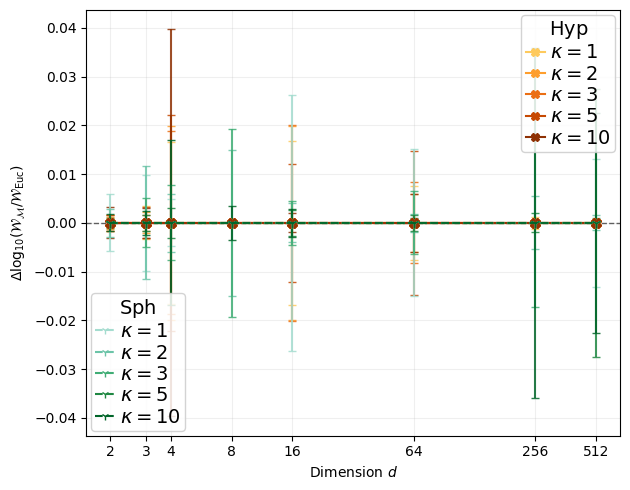

In [27]:
summary_by_curvature_mog = summarize_for_curvature_plot(rq3_prepared_mog)
summary_by_curvature_gtg = summarize_for_curvature_plot(rq3_prepared)
summary_by_curvature_rog = summarize_for_curvature_plot(rq3_prepared_gaussian_ring)
summary_by_curvature_gtg_norm = summarize_for_curvature_plot(rq3_prepared_norm)

# fig_b, ax_b = plot_rq3_dimension_vs_performance(
#     summary_by_curvature_gtg_norm,
#     hyp_legend_loc="upper right",
#     sph_legend_loc="lower left",
# )
# plt.show()

# fig_b, ax_b = plot_rq3_dimension_vs_performance(
#     summary_by_curvature_mog,
#     hyp_legend_loc="upper right",
#     sph_legend_loc="lower left",
# )
# plt.show()

# fig_b, ax_b = plot_rq3_dimension_vs_performance(
#     summary_by_curvature_gtg,
#     hyp_legend_loc="upper right",
#     sph_legend_loc="lower left",
# )
# plt.show()

fig_b, ax_b = plot_rq3_performance(
    summary_by_curvature_gtg,
    summary_by_curvature_gtg_norm,
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
)
plt.show()


# fig_b, ax_b = plot_rq3_dimension_vs_performance(
#     summary_by_curvature_rog,
#     hyp_legend_loc="upper right",
#     sph_legend_loc="lower left",
# )
# plt.show()

(<Figure size 640x500 with 1 Axes>,
 <Axes: xlabel='Dimension $d$', ylabel='$\\Delta \\log_{10}\\!\\left(\\mathcal{W}_{\\mathcal{M}}/\\mathcal{W}_{\\mathrm{Euc}}\\right)$'>)

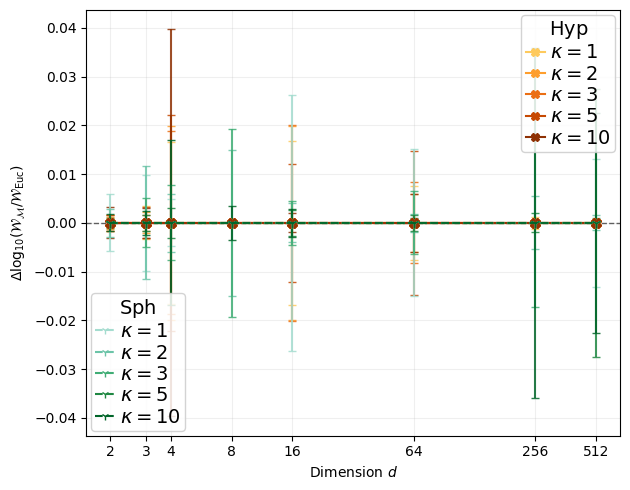

In [52]:
plot_rq3_2plots(
    summary_by_curvature_gtg,
    summary_by_curvature_gtg_nrom,
    figsize=(6.4, 5.0),
    hyp_legend_loc="upper right",
    sph_legend_loc="lower left",
)

In [27]:
def plot_rq3_combined_paper_style(
    summaries,
    task_titles = None,
    fs = 13,
    log_base = 10,
    savepath = "rq3_wasserstein_relative_dimension_combined.pdf",
    show_titles = False,
):
    global_ylim = _get_global_ylim_for_rq3(summaries, log_base = log_base)
    global_dims = _get_global_dims_for_rq3(summaries)

    fig, axes = plt.subplots(
        1,
        len(summaries),
        figsize = (3 * 1.618 * len(summaries), 3),
        sharey = True,
        squeeze = False,
    )

    axes = axes[0]
    log_factor = 1.0 / np.log10(log_base)

    for panel_idx, (ax, summary) in enumerate(zip(axes, summaries)):
        specs = get_rq3_style_specs(summary)

        for spec in specs["group_specs"]:
            sub = (
                spec["sub"]
                .dropna(subset=["compare_dim", "perf_mean"])
                .sort_values("compare_dim")
            )

            if sub.empty:
                continue

            y = sub["perf_mean"] * log_factor
            yerr = sub["perf_err"] * log_factor

            ax.errorbar(
                sub["compare_dim"],
                y,
                yerr = yerr,
                linestyle = spec["linestyle"],
                linewidth = 1.1,
                capsize = 3,
                marker = spec["marker"],
                markersize = 4.5,
                color = spec["color"],
                alpha = 0.95,
            )

        ax.set_xscale("log", base = 2)
        ax.set_xticks(global_dims)
        ax.set_xticklabels([nice_dim_label(d) for d in global_dims], fontsize = fs)

        ax.axhline(
            0,
            color = "black",
            linewidth = 0.9,
            linestyle = "--",
            alpha = 0.65,
        )

        ax.set_xlabel(r"$d$", fontsize = fs + 1)
        ax.set_ylim(*global_ylim)

        ax.grid(
            True,
            linewidth = 0.5,
            alpha = 0.4,
            linestyle = "dashed",
        )

        ax.tick_params(axis = "y", labelsize = fs)

        if panel_idx > 0:
            ax.tick_params(labelleft = False)

        if show_titles and task_titles is not None:
            ax.set_title(task_titles[panel_idx], fontsize = fs + 1, fontweight = "bold")

        if panel_idx == 0:
            ax.set_ylabel(
                rf"$\log_{{{log_base}}}(W_{{\mathcal{{M}}}}/W_{{\mathrm{{Euclidean}}}})$",
                fontsize = fs + 1,
            )

        if panel_idx == 0:
            hyp_handles = _make_legend_handles(specs, POINCARE_NAME)
            ax.legend(
                handles = hyp_handles,
                loc = "upper center",
                bbox_to_anchor = (0.5, 0.98),
                ncol = 3,
                fontsize = fs - 1,
                frameon = False,
                columnspacing = 0.9,
                handletextpad = 0.45,
                borderaxespad = 0.2,
            )

        if panel_idx == 1:
            sph_handles = _make_legend_handles(specs, SPHERE_NAME)
            ax.legend(
                handles = sph_handles,
                loc = "upper center",
                bbox_to_anchor = (0.5, 0.98),
                ncol = 3,
                fontsize = fs - 1,
                frameon = False,
                columnspacing = 0.9,
                handletextpad = 0.45,
                borderaxespad = 0.2,
            )

    fig.subplots_adjust(
        left = 0.07,
        right = 0.995,
        bottom = 0.22,
        top = 0.96,
        wspace = 0.08,
    )

    if savepath is not None:
        fig.savefig(
            savepath,
            format = "pdf",
            bbox_inches = None,
            pad_inches = 0,
        )

    plt.show()

    return fig, axes


fig_rq3_combined, axes_rq3_combined = plot_rq3_combined_paper_style(
    summaries = [
        summary_by_curvature_gtg,
        summary_by_curvature_rog,
        summary_by_curvature_mog,
    ],
    task_titles = [
        "Gaussian-to-Gaussian",
        "Symmetric Gaussian Shell",
        "Mixture of Gaussians",
    ],
    fs = 15,
    log_base = 10,
    savepath = "rq3_wasserstein_non_relative_dimension_combined.pdf",
    show_titles = False,
)

NameError: name '_get_global_ylim_for_rq3' is not defined